Here '!' is used to indicate that use this as shell command rather than python command

In [ ]:
!pip install datasets optuna rasterio pyproj rioxarray joblib matplotlib seaborn folium

   ---------------------------------------- 0.0/566.1 kB ? eta -:--:--
   ---------------------------------------- 566.1/566.1 kB ?  0:00:00
   ---------------------------------------- 0.0/25.5 MB ? eta -:--:--
   ------------------ --------------------- 11.8/25.5 MB 56.5 MB/s eta 0:00:01
   -------------------------- ------------- 16.8/25.5 MB 48.0 MB/s eta 0:00:01
   ---------------------------------------- 25.5/25.5 MB 46.1 MB/s  0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 6.3/6.3 MB 64.5 MB/s  0:00:00
   ---------------------------------------- 0.0/28.1 MB ? eta -:--:--
   ------------------------------- -------- 22.3/28.1 MB 107.9 MB/s eta 0:00:01
   ---------------------------------------- 28.1/28.1 MB 89.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 60.3 MB/s  0:00:00
   ----------------------------------------

In [12]:
!pip install  -U scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 8.9/8.9 MB 91.8 MB/s  0:00:00
   ---------------------------------------- 0.0/38.7 MB ? eta -:--:--
   ------------------------- -------------- 24.4/38.7 MB 118.8 MB/s eta 0:00:01
   ---------------------------------------- 38.7/38.7 MB 98.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   ------------- -------------------------- 1/3 [scipy]
   -----------

#### Download and install folium_helper package

In [31]:
import urllib.request

url = "https://raw.githubusercontent.com/NASAARSET/ARSET_ML_Fundamentals/main/src/folium_helper.py"
filename = "folium_helper.py"

urllib.request.urlretrieve(url, filename)

('folium_helper.py', <http.client.HTTPMessage at 0x1d9db1a5250>)

In [33]:
import os
import sys
import csv
import time
import glob
import joblib
import datasets
import datetime
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray import merge
from pathlib import Path
from pprint import pprint
from huggingface_hub import snapshot_download

from sklearn.ensemble import RandomForestClassifier as skRF
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.inspection import permutation_importance

# import useful packages
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import natsort

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Geospatial related imports
from osgeo import gdalconst
from osgeo import gdal
import folium

from folium import plugins
import folium_helper

plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')
%matplotlib inline


#### Which scientific question would you like address? What are potential drivers led to change in surface water extent
1. This is binary classification problem where we are going to classify whether it is water or not

In [34]:
DATASET_URL = "nasa-cisto-data-science-group/modis-lake-powell-toy-dataset"

In [36]:
powell_dataset = snapshot_download(repo_id=DATASET_URL, allow_patterns="*.tif", repo_type='dataset')

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is 

In [37]:
print(powell_dataset)

C:\Users\shah0012\.cache\huggingface\hub\datasets--nasa-cisto-data-science-group--modis-lake-powell-toy-dataset\snapshots\e22fb0ce2c73d603ff182183fbfc1476d0032d1d


In [39]:
filelist = sorted([file for file in glob.glob(os.path.join(powell_dataset, 'IL.*.Powell.*.tif')) if 'sur_refl' in file])

In [41]:
raster_arrays = []

for val in filelist:
    raster_arrays.append(rxr.open_rasterio(val))
raster = xr.concat(raster_arrays, dim ="band")
raster

<xarray.DataArray (band: 7, y: 1300, x: 1300)> Size: 24MB
array([[[1547, 1474, 1474, ..., 3151, 3151, 3087],
        [1395, 1395, 1379, ..., 3323, 3323, 3148],
        [1408, 1403, 1379, ..., 3223, 3223, 3203],
        ...,
        [2196, 2186, 2255, ..., 2193, 2253, 2230],
        [2186, 2255, 2341, ..., 2154, 2235, 2217],
        [2320, 2439, 2169, ..., 2358, 2425, 2402]],

       [[2461, 2377, 2377, ..., 4079, 4079, 4081],
        [2340, 2340, 2365, ..., 4276, 4276, 4170],
        [2343, 2387, 2365, ..., 4206, 4206, 4153],
        ...,
        [3175, 3132, 3207, ..., 2858, 2858, 2820],
        [3132, 3207, 3310, ..., 2776, 2853, 2854],
        [3284, 3392, 3113, ..., 2979, 3069, 3038]],

       [[ 857,  857,  846, ..., 1669, 1565, 1565],
        [ 857,  857,  846, ..., 1669, 1565, 1565],
        [ 812,  812,  822, ..., 1565, 1565, 1565],
        ...,
...
        [4066, 4066, 4012, ..., 3650, 3672, 3672],
        [3981, 3981, 3951, ..., 3633, 3747, 3747],
        [3981, 3981, 3951, ..., 3633, 3747, 3747]],

       [[2730, 2730, 2613, ..., 5380, 5259, 5259],
        [2730, 2730, 2613, ..., 5380, 5259, 5259],
        [2587, 2587, 2592, ..., 5259, 5259, 5259],
        ...,
        [4343, 4343, 4330, ..., 4266, 4247, 4247],
        [4235, 4235, 4235, ..., 4223, 4345, 4345],
        [4235, 4235, 4235, ..., 4223, 4345, 4345]],

       [[2222, 2222, 2098, ..., 4809, 4576, 4576],
        [2222, 2222, 2098, ..., 4809, 4576, 4576],
        [2075, 2075, 2117, ..., 4576, 4576, 4576],
        ...,
        [3826, 3826, 3766, ..., 3862, 3863, 3863],
        [3694, 3694, 3739, ..., 3863, 3919, 3919],
        [3694, 3694, 3739, ..., 3863, 3919, 3919]]],
      shape=(7, 1300, 1300), dtype=int16)
Coordinates:
  * band         (band) int64 56B 1 1 1 1 1 1 1
  * y            (y) float64 10kB 4.61e+06 4.61e+06 ... 4.309e+06 4.309e+06
  * x            (x) float64 10kB -1.005e+07 -1.005e+07 ... -9.753e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -9999
    scale_factor:   1.0
    add_offset:     0.0

Here xarray will *raster[:3, :, :]* as RGB image. imshow() displays the results as color image. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8672..1.0].


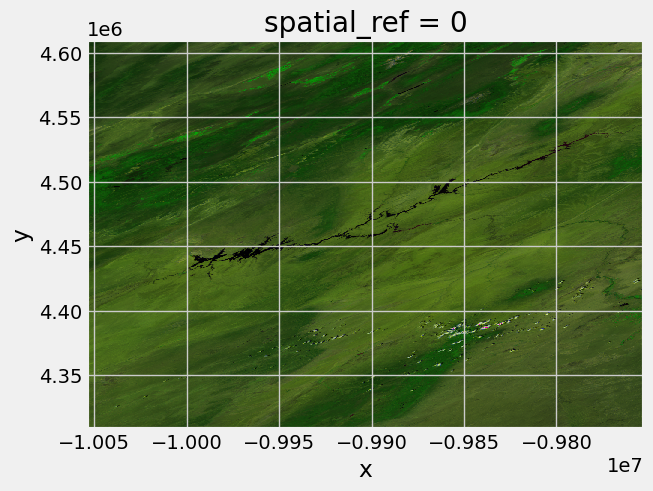

In [45]:
(raster[:3, :, :]/10000).plot.imshow()

Below will plot a single band as a grayscale image

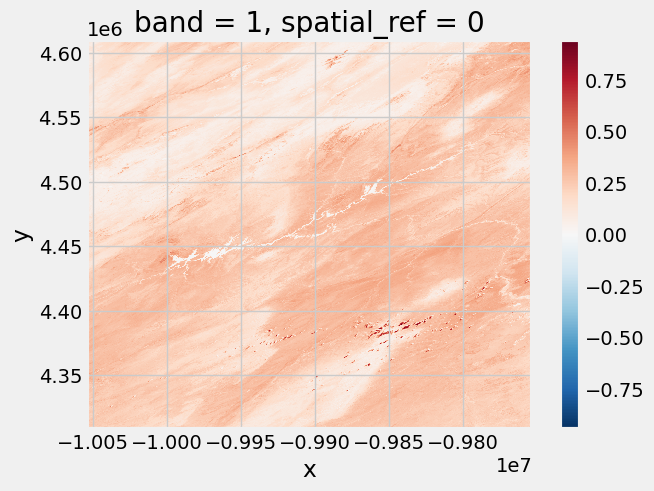

In [52]:
(raster[0, :, :]/10000).plot.imshow()

### K-means clustering

In [56]:
N_CLUSTERS = 4

nbands = raster.shape[0]

# create an empty array in which each column will hold flattened band
flat_data = np.empty((raster.shape[1]*raster.shape[2], nbands))

print(f"Shape of the flat data has {flat_data.shape[0]} rows and {flat_data.shape[1]} columns")

# loop through each band in the image and add the data array

for i in range(nbands):
    band = raster[i, :, :].values
    flat_data[:, i-1] = band.flatten()


# set up the kmean classification by sepcifying the number of clusters
km = KMeans(n_clusters=N_CLUSTERS)

km.fit(flat_data)

Shape of the flat data has 1690000 rows and 7 columns


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [59]:
print(band.shape)
print(band.flatten().shape)


(1300, 1300)
(1690000,)


In [ ]:
flat_data.shape

(1690000, 7)

In [60]:
flat_data

array([[2461.,  857., 1256., ..., 2730., 2222., 1547.],
       [2377.,  857., 1256., ..., 2730., 2222., 1474.],
       [2377.,  846., 1230., ..., 2613., 2098., 1474.],
       ...,
       [2979., 1028., 1791., ..., 4223., 3863., 2358.],
       [3069., 1117., 1876., ..., 4345., 3919., 2425.],
       [3038., 1117., 1876., ..., 4345., 3919., 2402.]],
      shape=(1690000, 7))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8672..0.9424].


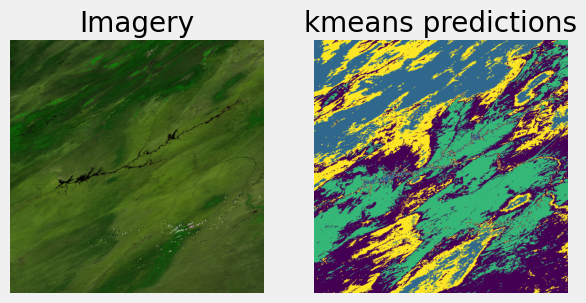

In [61]:
flat_predictions = km.predict(flat_data)

# reshape the flattened prediction array into an M*N prediction mask
prediction_mask = flat_predictions.reshape((raster.shape[1], raster.shape[2]))

# plot the imagery and the prediction mask for comparison
f, axarr = plt.subplots(1, 2)
axarr[0].imshow(np.moveaxis(raster[:3, :, :].values, 0, -1)/10000)
axarr[0].set_title("Imagery")
axarr[1].imshow(prediction_mask)
axarr[1].set_title("kmeans predictions")

axarr[0].axis("off")
axarr[1].axis("off")

plt.show()

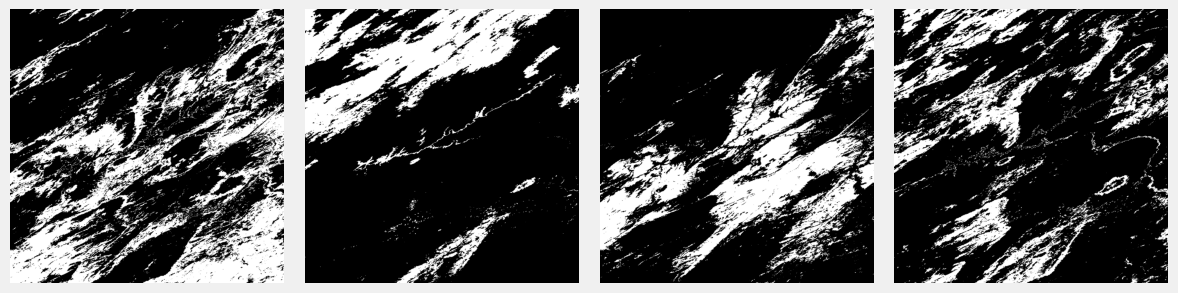

In [64]:
fig, axes = plt.subplots(1,4, figsize = (12, 12))

for n, ax in enumerate(axes.flatten()):
    ax.imshow(prediction_mask==[n], cmap = "gray")
    ax.set_axis_off()

fig.tight_layout()

![image](https://1.bp.blogspot.com/-Ax59WK4DE8w/YK6o9bt_9jI/AAAAAAAAEQA/9KbBf9cdL6kOFkJnU39aUn4m8ydThPenwCLcBGAsYHQ/s0/Random%2BForest%2B03.gif)

![image](https://dz2cdn1.dzone.com/storage/temp/13069527-boosting-algo.png)


![image](https://miro.medium.com/v2/resize:fit:720/format:webp/1*QJZ6W-Pck_W7RlIDwUIN9Q.jpeg)